In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
filepaths = ["../data/lavender.csv"]

In [6]:
dfs = [pd.read_csv(path) for path in filepaths]
df = pd.concat(dfs)
print(len(df))
df.head()

9200


,id_timestamp,id_index,sensor_index,sensor_id,timestamp_since_poweron,real_time_clock,temperature,pressure,relative_humidity,resistance_gassensor,heater_profile_step_index,scanning_enabled,scanning_cycle_index,label_tag,error_code
0,2026_02_19_08_29,0,0,1724206365,5500,1771489795,25.381390,996.021851,46.705666,15094.339844,0,1,1,0,0
1,2026_02_19_08_29,1,1,1724192798,5505,1771489795,25.568531,996.254761,46.286995,10126.582031,0,1,1,0,0
2,2026_02_19_08_29,2,2,1724204062,5509,1771489795,25.561659,996.258789,46.099087,11095.700195,0,1,1,0,0
3,2026_02_19_08_29,3,3,1724221471,5514,1771489795,25.486506,996.079590,45.770355,11539.848633,0,1,1,0,0
4,2026_02_19_08_29,4,4,1724209694,5518,1771489795,25.549452,996.051636,44.604366,14295.287109,0,1,1,0,0


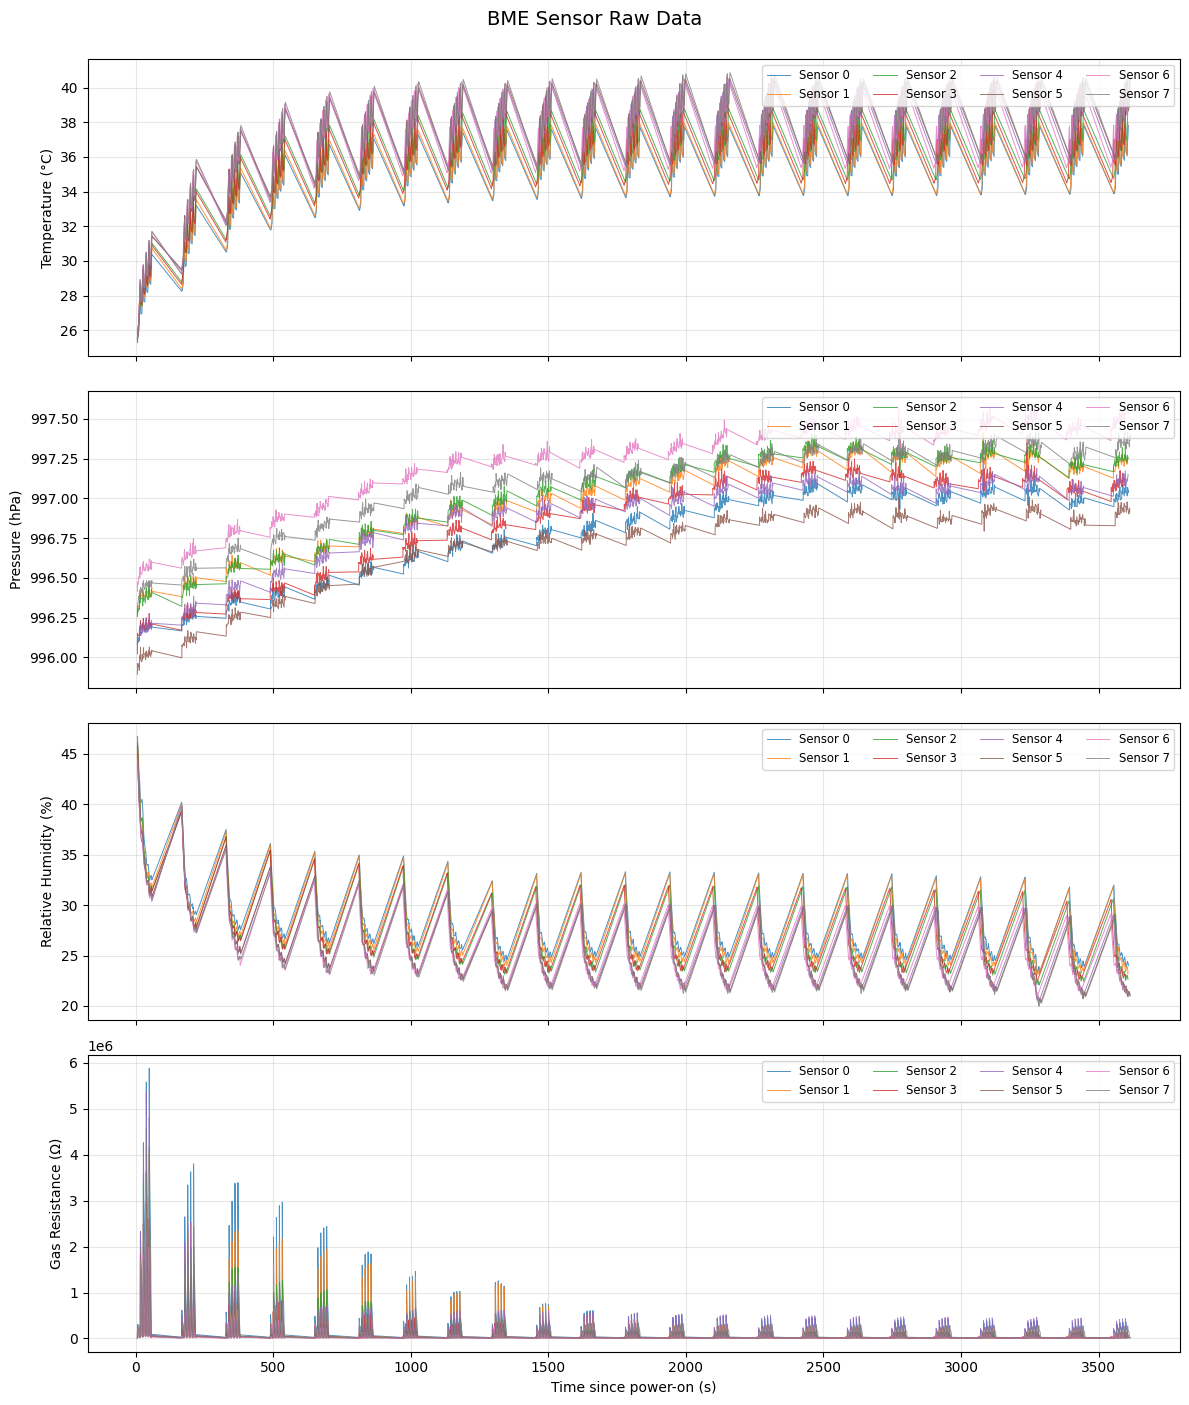

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

metrics = [
    ("temperature", "Temperature (°C)"),
    ("pressure", "Pressure (hPa)"),
    ("relative_humidity", "Relative Humidity (%)"),
    ("resistance_gassensor", "Gas Resistance (\u03a9)"),
]

for ax, (col, label) in zip(axes, metrics):
    for sensor_id, group in df.groupby("sensor_index"):
        ax.plot(group["timestamp_since_poweron"] / 1000, group[col],
                label=f"Sensor {sensor_id}", linewidth=0.7, alpha=0.8)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize="small", ncol=4)

axes[-1].set_xlabel("Time since power-on (s)")
fig.suptitle("BME Sensor Raw Data", fontsize=14, y=1.0)
fig.tight_layout()
plt.show()